## 0 - Setup (run this first)

This notebook is the hands-on part of today's session on **sequence models**. We will turn a real
hourly weather record into a forecasting problem, then build a short ladder of models, from a plain
dense network up to an LSTM, where each model fixes a specific weakness of the one before it.

Run the two cells below first: they import the libraries and download the dataset.


In [1]:
# Standard scientific stack, all preinstalled on Colab.
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility (we'll talk about why this matters on Thursday)
keras.utils.set_random_seed(42)

# UW-purple styling for our plots
UW_PURPLE, UW_GOLD, UW_PINK = "#4B2E83", "#85754D", "#C42A8B"
plt.rcParams.update({"axes.edgecolor": "#6B6580", "axes.labelcolor": "#221C35",
                     "figure.facecolor": "white", "axes.grid": True,
                     "grid.color": "#E5E0EE", "grid.linewidth": 0.8})

print("TensorFlow:", tf.__version__)
print("GPU available:", "YES" if tf.config.list_physical_devices('GPU') else "no (CPU is fine for today)")

TensorFlow: 2.20.0
GPU available: YES


In [2]:
# Download the Jena Climate dataset (weather near Jena, Germany; 2009–2016,
# recorded every 10 minutes). ~13 MB, cached after the first run.
import os
from zipfile import ZipFile

zip_path = keras.utils.get_file(
    "jena_climate_2009_2016.csv.zip",
    "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
)
csv_dir = os.path.dirname(zip_path)
csv_path = os.path.join(csv_dir, "jena_climate_2009_2016.csv")
if not os.path.exists(csv_path):
    with ZipFile(zip_path) as z:
        z.extractall(csv_dir)
print("CSV ready at:", csv_path)

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
CSV ready at: /root/.keras/datasets/jena_climate_2009_2016.csv


## 1 - Meet the data, and why order matters

This morning you worked with **fixed-size inputs**: an image is always the same grid of pixels, and
the whole grid is available to the model at once.

A **sequence** is different. Formally, a sequence is an ordered list of values x_1, x_2, ..., x_T,
and three properties define it:

- **Order carries meaning.** Swapping two elements can change or destroy the meaning entirely.
  "The dog bit the man" and "The man bit the dog" use the same words but describe different events.
- **Length can vary.** A sentence can be five words or fifty; a weather record can span a day or a
  decade.
- **Nearby elements tend to be related.** Today's temperature is a strong clue about tomorrow's; the
  previous word in a sentence constrains which word is likely to come next.

Sequential data is everywhere: text (a sequence of words), audio (a sequence of amplitude samples),
DNA (a sequence of nucleotides), sensor logs, stock prices, and, in our case today, hourly
temperature readings. A model that treats these values as an unordered bag of numbers throws away
exactly the information that sequence models are designed to use.


<div align="center">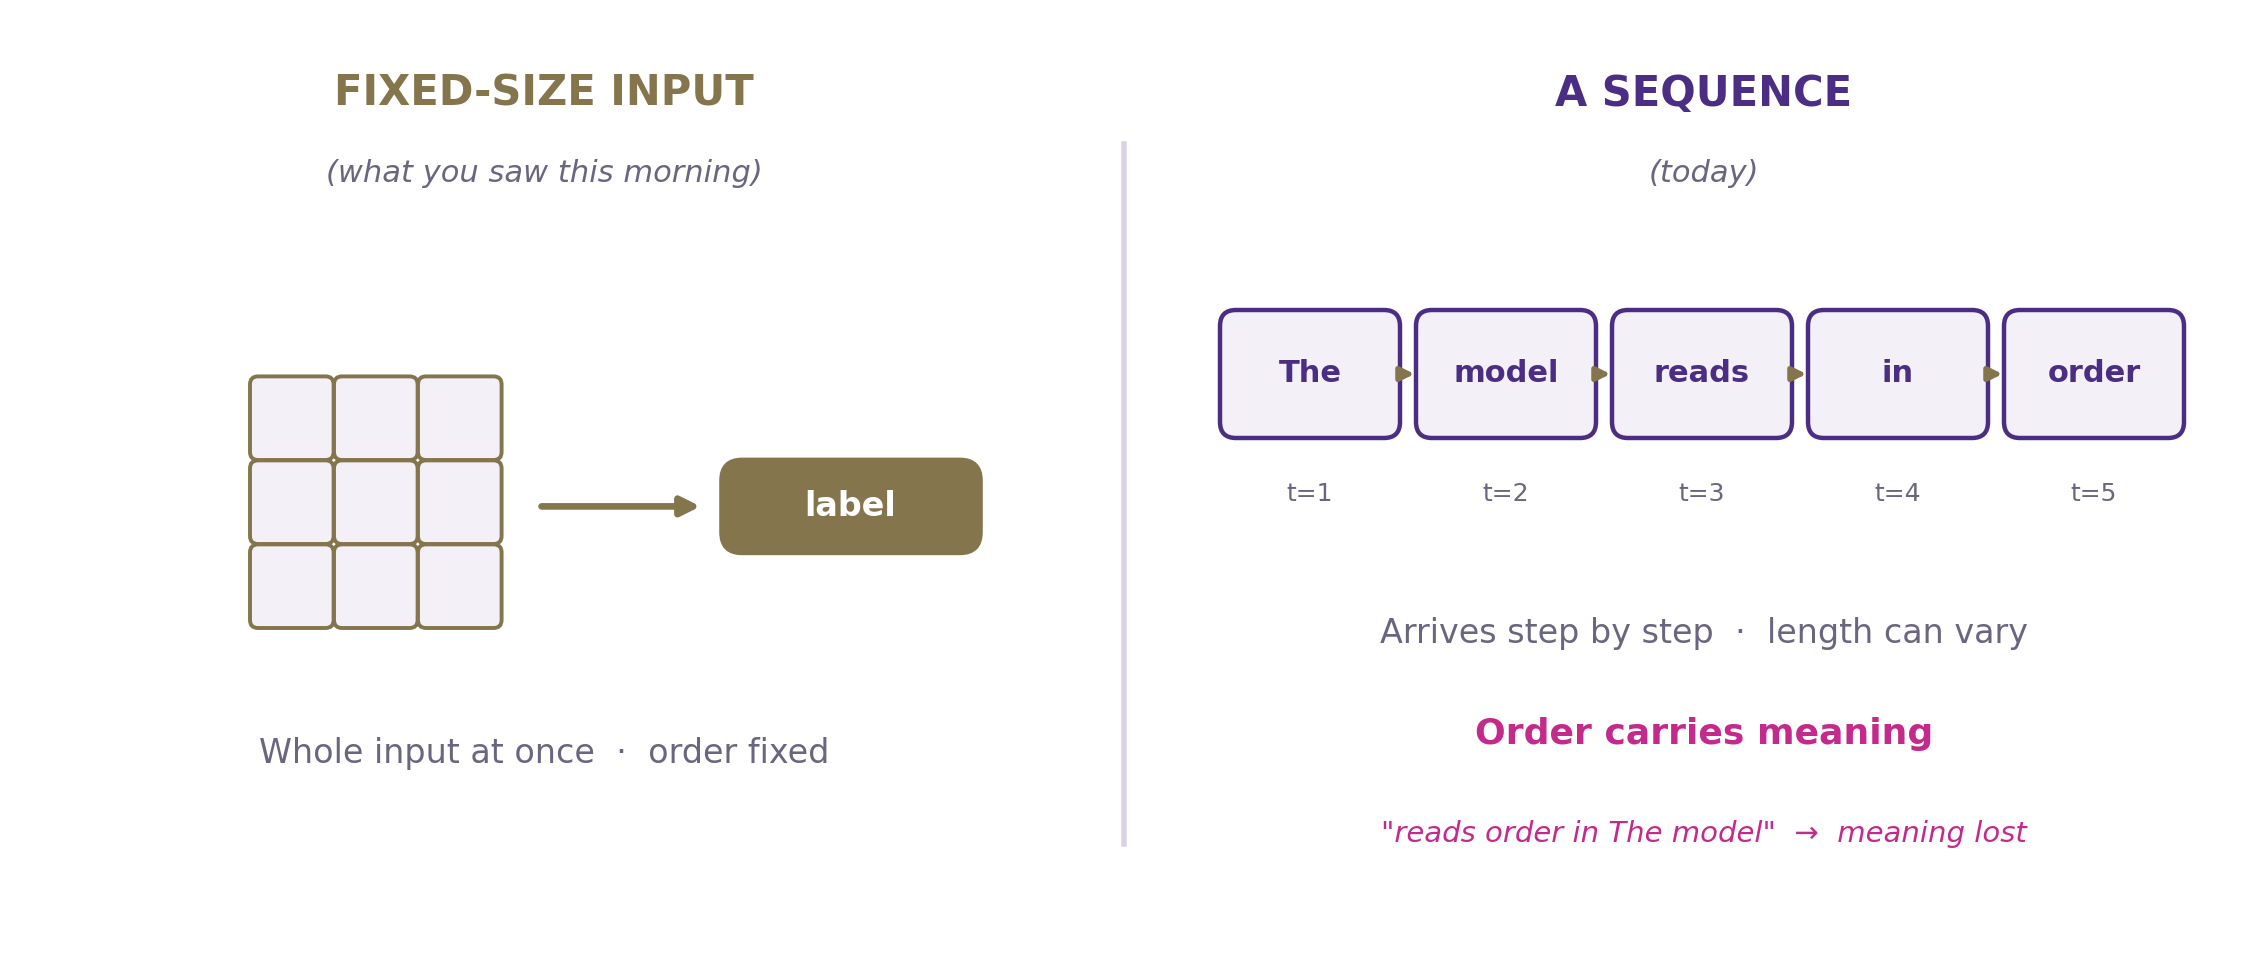</div>

In [3]:
# Read the CSV with plain numpy (no pandas needed).
raw = np.genfromtxt(csv_path, delimiter=",", skip_header=1,
                    usecols=range(1, 15), invalid_raise=False)
header = open(csv_path).readline().strip().split(",")
col_names = [c.strip('"') for c in header[1:15]]
print("Columns:", col_names)

# Temperature is the "T (degC)" column
TEMP_COL = col_names.index("T (degC)")
temperature = raw[:, TEMP_COL].astype("float32")
print("Total 10-minute readings:", len(temperature))

Columns: ['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
Total 10-minute readings: 420551


Hourly readings: 70092


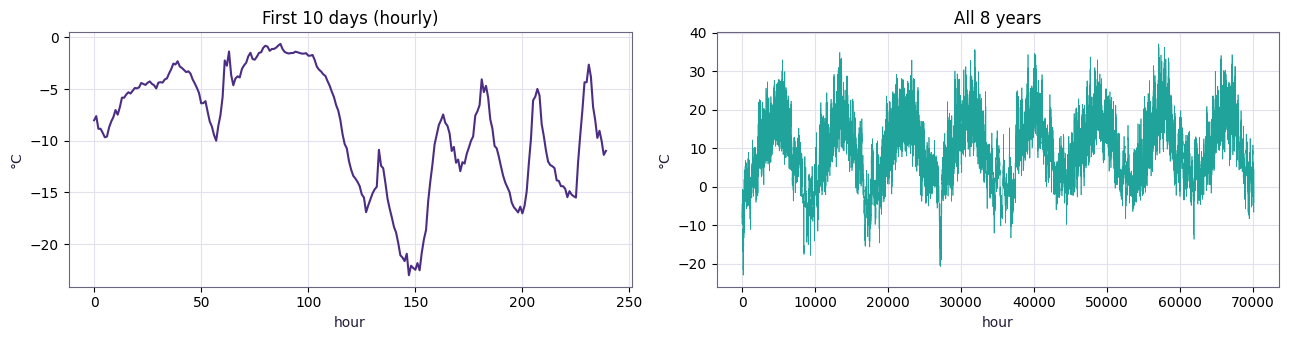

In [4]:
# 10-minute data is dense and slow to train on. Resample to HOURLY (every 6th row).
temp = temperature[::6]
print("Hourly readings:", len(temp))

fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
ax[0].plot(temp[:24*10], color=UW_PURPLE)
ax[0].set_title("First 10 days (hourly)"); ax[0].set_xlabel("hour"); ax[0].set_ylabel("°C")
ax[1].plot(temp, color="#1FA39B", lw=0.5)
ax[1].set_title("All 8 years"); ax[1].set_xlabel("hour"); ax[1].set_ylabel("°C")
plt.tight_layout(); plt.show()

**Discuss:** notice the daily cycle in the 10-day plot and the yearly cycle in the 8-year plot.
Both are signals a forecasting model can exploit: today's temperature is correlated with yesterday's
(the daily cycle) and with the temperature around the same time last year (the yearly cycle). A good
model uses the recent past to anticipate the near future. That is our task below.


## 2 - Frame the forecast: windowing

Neural networks are trained with **supervised learning**: pairs of (input, target). A raw
temperature series is just one long sequence of numbers, with no obvious inputs or targets, so
before training anything we need to turn it into a supervised learning problem.

The standard technique is a **sliding window**: cut a fixed-length stretch of the past (the input)
and pair it with a single value some fixed distance later (the target). Sliding this window forward
one step at a time turns one long series into thousands of overlapping
`(input window -> future target)` examples. Getting this framing right matters more than any model
choice that follows: get it wrong, for example by letting future values leak into the input, and
every model built on top of it will look artificially good or bad.

<div align="center">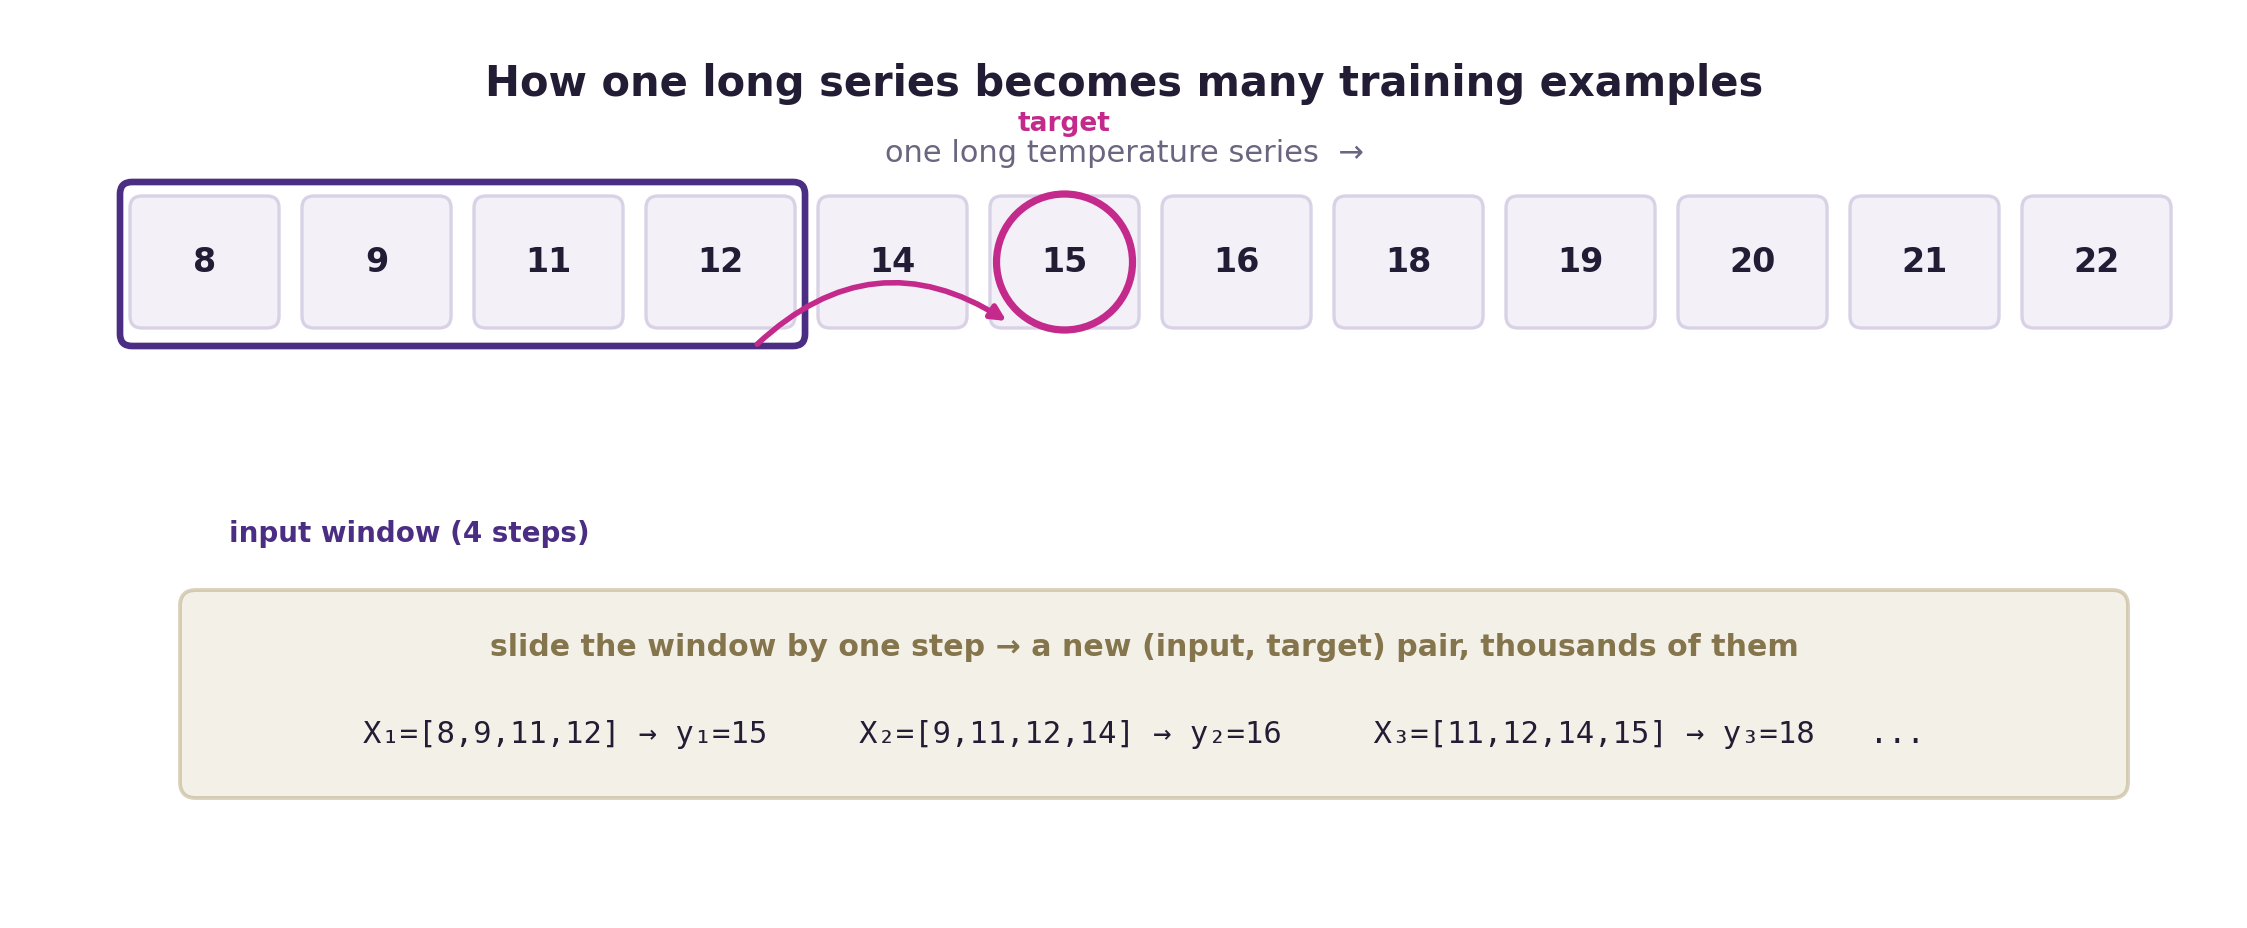</div>

- **Input:** the last `SEQ_LEN` hours of temperature. **Target:** the temperature `DELAY` hours
  *after* the window ends.
- `SEQ_LEN` controls how much history the model can see (its receptive field in time); `DELAY`
  controls how far ahead we are forecasting (the forecast horizon).


In [5]:
# --- Problem settings ---------------------------------------------------
SEQ_LEN  = 48     # look back 48 hours (2 days)
DELAY    = 24     # predict the temperature 24 hours ahead
BATCH    = 128

FAST_DEMO = True  # ← keeps the live session snappy. Set False for full data / better numbers.
if FAST_DEMO:
    temp_use = temp[:25000]    # ~3 years, trains in seconds–minutes
    EPOCHS   = 10
else:
    temp_use = temp
    EPOCHS   = 25

# Chronological split: train on the PAST, validate/test on the FUTURE (never shuffle across time!)
n   = len(temp_use)
ntr = int(n * 0.6)
nva = int(n * 0.2)
print(f"train {ntr} | val {nva} | test {n-ntr-nva} hours")

train 15000 | val 5000 | test 5000 hours


In [6]:
# Normalize using TRAIN statistics only (don't peek at val/test).
mu = temp_use[:ntr].mean()
sd = temp_use[:ntr].std()
norm = ((temp_use - mu) / sd).astype("float32").reshape(-1, 1)   # shape (n, 1): one feature
print(f"train mean={mu:.2f}°C  std={sd:.2f}°C")

train mean=9.00°C  std=8.99°C


Keras provides a utility, `timeseries_dataset_from_array`, that implements exactly this
sliding-window slicing for us, so we do not have to write the indexing logic by hand.


In [7]:
def make_dataset(arr, start, end, shuffle):
    inputs  = arr[start : end - DELAY]
    targets = arr[start + SEQ_LEN + DELAY - 1 : end, 0]
    return keras.utils.timeseries_dataset_from_array(
        inputs, targets, sequence_length=SEQ_LEN, batch_size=BATCH, shuffle=shuffle)

train_ds = make_dataset(norm, 0,        ntr,      shuffle=True)
val_ds   = make_dataset(norm, ntr,      ntr+nva,  shuffle=False)
test_ds  = make_dataset(norm, ntr+nva,  n,        shuffle=False)

for x, y in train_ds.take(1):
    print("input batch :", x.shape, "  <- (batch, SEQ_LEN, 1 feature)")
    print("target batch:", y.shape)
N_FEAT = x.shape[-1]

input batch : (128, 48, 1)   <- (batch, SEQ_LEN, 1 feature)
target batch: (128,)


**See it concretely.** The cell below prints two *consecutive* windows from the real data,
so you can watch the window slide by one step: the same idea as the diagram above, now with actual
numbers.


In [8]:
xb, yb = next(iter(val_ds))          # val_ds is unshuffled, so samples are consecutive
print("window 0 (first 6 hrs, normalized):", np.round(xb[0, :6, 0].numpy(), 2), "...")
print("window 1 (first 6 hrs, normalized):", np.round(xb[1, :6, 0].numpy(), 2), "...  ← slid by one step")
print()
print(f"their targets in °C: {yb[0]*sd+mu:.1f}  and  {yb[1]*sd+mu:.1f}")

window 0 (first 6 hrs, normalized): [0.19 0.14 0.13 0.13 0.12 0.13] ...
window 1 (first 6 hrs, normalized): [0.14 0.13 0.13 0.12 0.13 0.12] ...  ← slid by one step

their targets in °C: 6.8  and  6.4


## 3 - The naive baseline and MAE

Before training any neural network, we need a baseline: a simple rule that any real model must beat
to be worth using. In forecasting, the standard baseline is **persistence**: predict that the future
value equals the most recent observed value ("tomorrow's temperature is about the same as right
now"). Persistence works surprisingly well for smooth, slowly changing signals like temperature,
which is exactly why it makes a fair and demanding baseline.

We measure error with **Mean Absolute Error (MAE)**:

`MAE = average of |prediction - actual|` over all examples.

MAE is reported in the same units as the target (degrees Celsius here), so an MAE of 2.0 means the
model is, on average, off by about 2 degrees. That makes it much easier to interpret than a
squared-error metric.

<div align="center">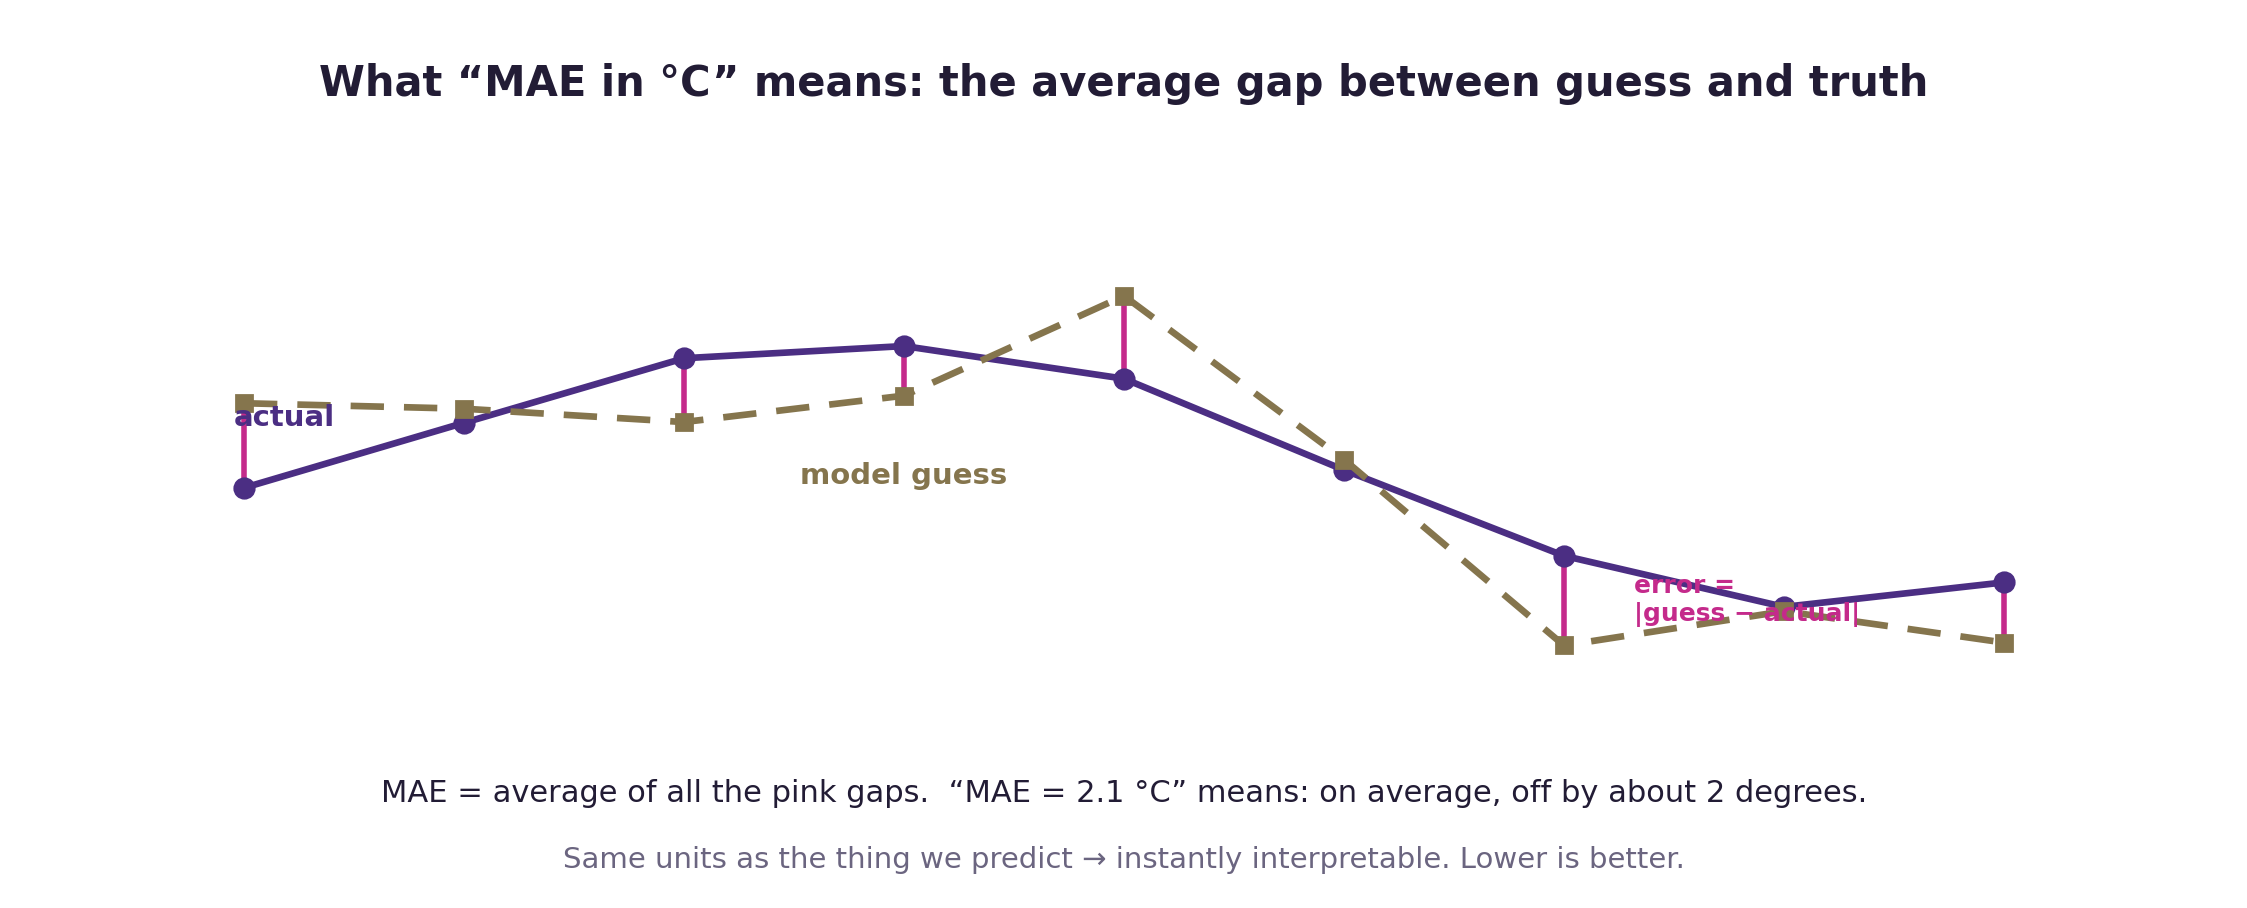</div>

In [9]:
def naive_mae(ds):
    errs = []
    for x, y in ds:
        last_value = x[:, -1, 0]                 # last hour in each window
        errs.append(tf.reduce_mean(tf.abs(last_value - y)))
    return float(tf.reduce_mean(errs)) * sd      # back to °C

baseline_mae = naive_mae(val_ds)
print(f"Naive baseline MAE: {baseline_mae:.2f} °C   ← write this on the board!")

Naive baseline MAE: 2.82 °C   ← write this on the board!


## 4 - A training helper

Every model below will be compiled, trained, and evaluated the same way. Rather than repeat that
boilerplate five times, we wrap it in one helper function so the rest of the notebook can focus on
what actually changes between models: the architecture.


In [10]:
results = {"naive": baseline_mae}        # collect every model's MAE here

early = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

def train_and_score(model, name):
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    hist = model.fit(train_ds, validation_data=val_ds,
                     epochs=EPOCHS, callbacks=[early], verbose=0, shuffle=False)
    mae_C = model.evaluate(val_ds, verbose=0)[1] * sd
    results[name] = mae_C
    print(f"{name:>10s}  val MAE = {mae_C:5.2f} °C   "
          f"({'beats' if mae_C < baseline_mae else 'loses to'} naive {baseline_mae:.2f})")
    return hist

## 5 - A ladder of models

We will train five models on the same data with the same evaluation metric. Each one is a small
change from the last, and each change fixes a specific weakness of the model before it. Keep the
table below in view as a map for what follows:

<div align="center">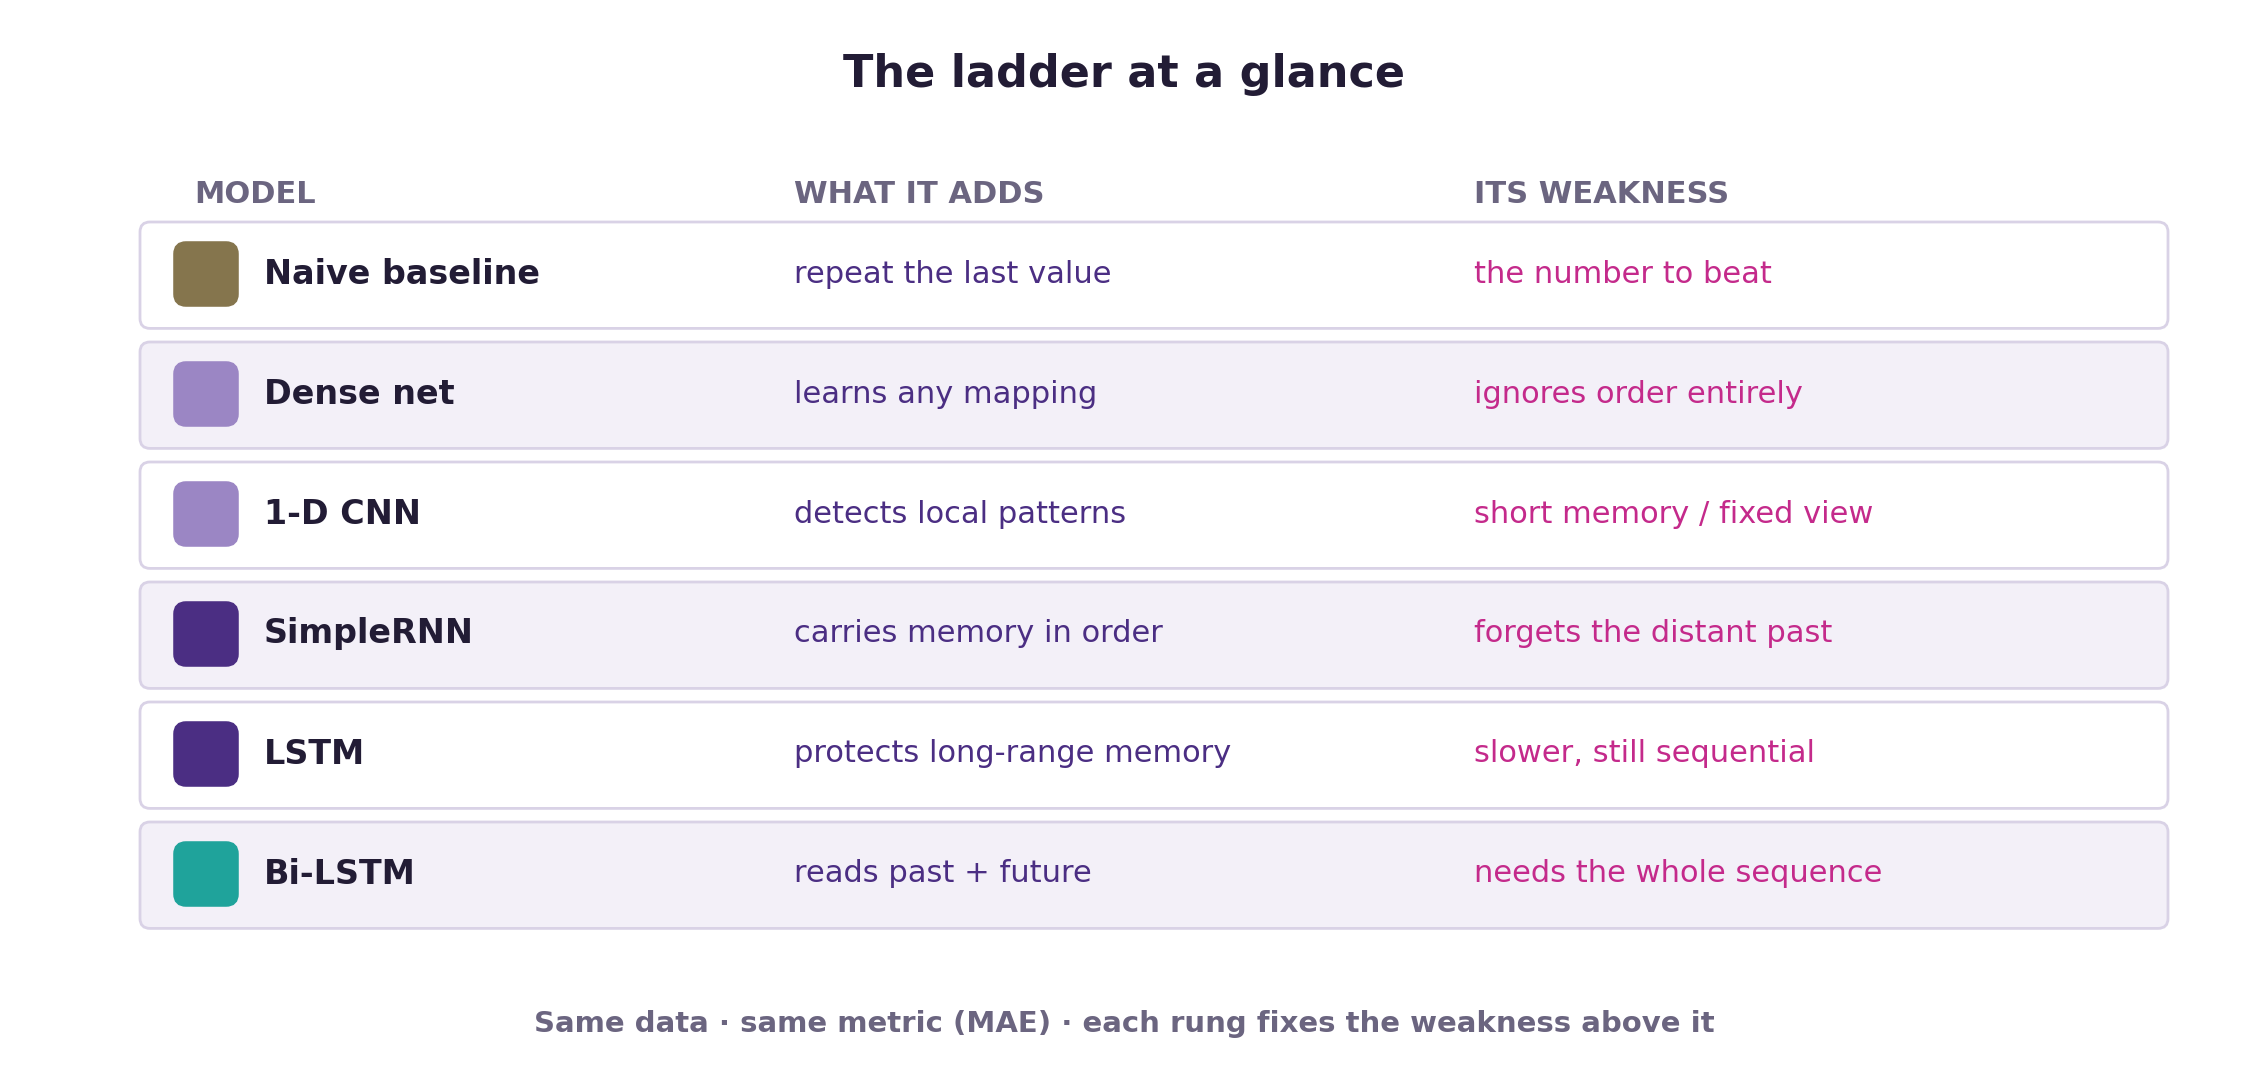</div>

### 5a - Dense network: ignores order

A fully connected (dense) layer takes a fixed-size vector and learns a weighted combination of its
entries. To use one here, we first `Flatten` the window from shape `(SEQ_LEN, N_FEAT)` into a single
vector of `SEQ_LEN * N_FEAT` numbers.

This works, in the sense that the network can still learn a useful mapping. But flattening discards
the window's structure: position 1 and position 48 become two entries in a list, with nothing telling
the model that one came before the other, or how far apart they are. The model has to learn any
temporal structure from scratch, and the number of parameters grows with the window length.


In [11]:
dense = keras.Sequential([
    keras.Input(shape=(SEQ_LEN, N_FEAT)),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(1),
])
train_and_score(dense, "dense")

     dense  val MAE =  2.77 °C   (beats naive 2.82)


### 5b - 1-D convolution: local patterns

A **1-D convolution** applies the same small filter (a short vector of learned weights) at every
position along the sequence, computing a weighted sum over a short window as it slides. Because the
same filter is reused everywhere, the network learns to detect a local pattern, such as a sudden
spike or dip, wherever it occurs, using far fewer parameters than a dense layer would need for the
same job. This weight sharing is the same idea a 2-D CNN uses on images, applied along a single time
axis instead of two spatial axes.

<div align="center">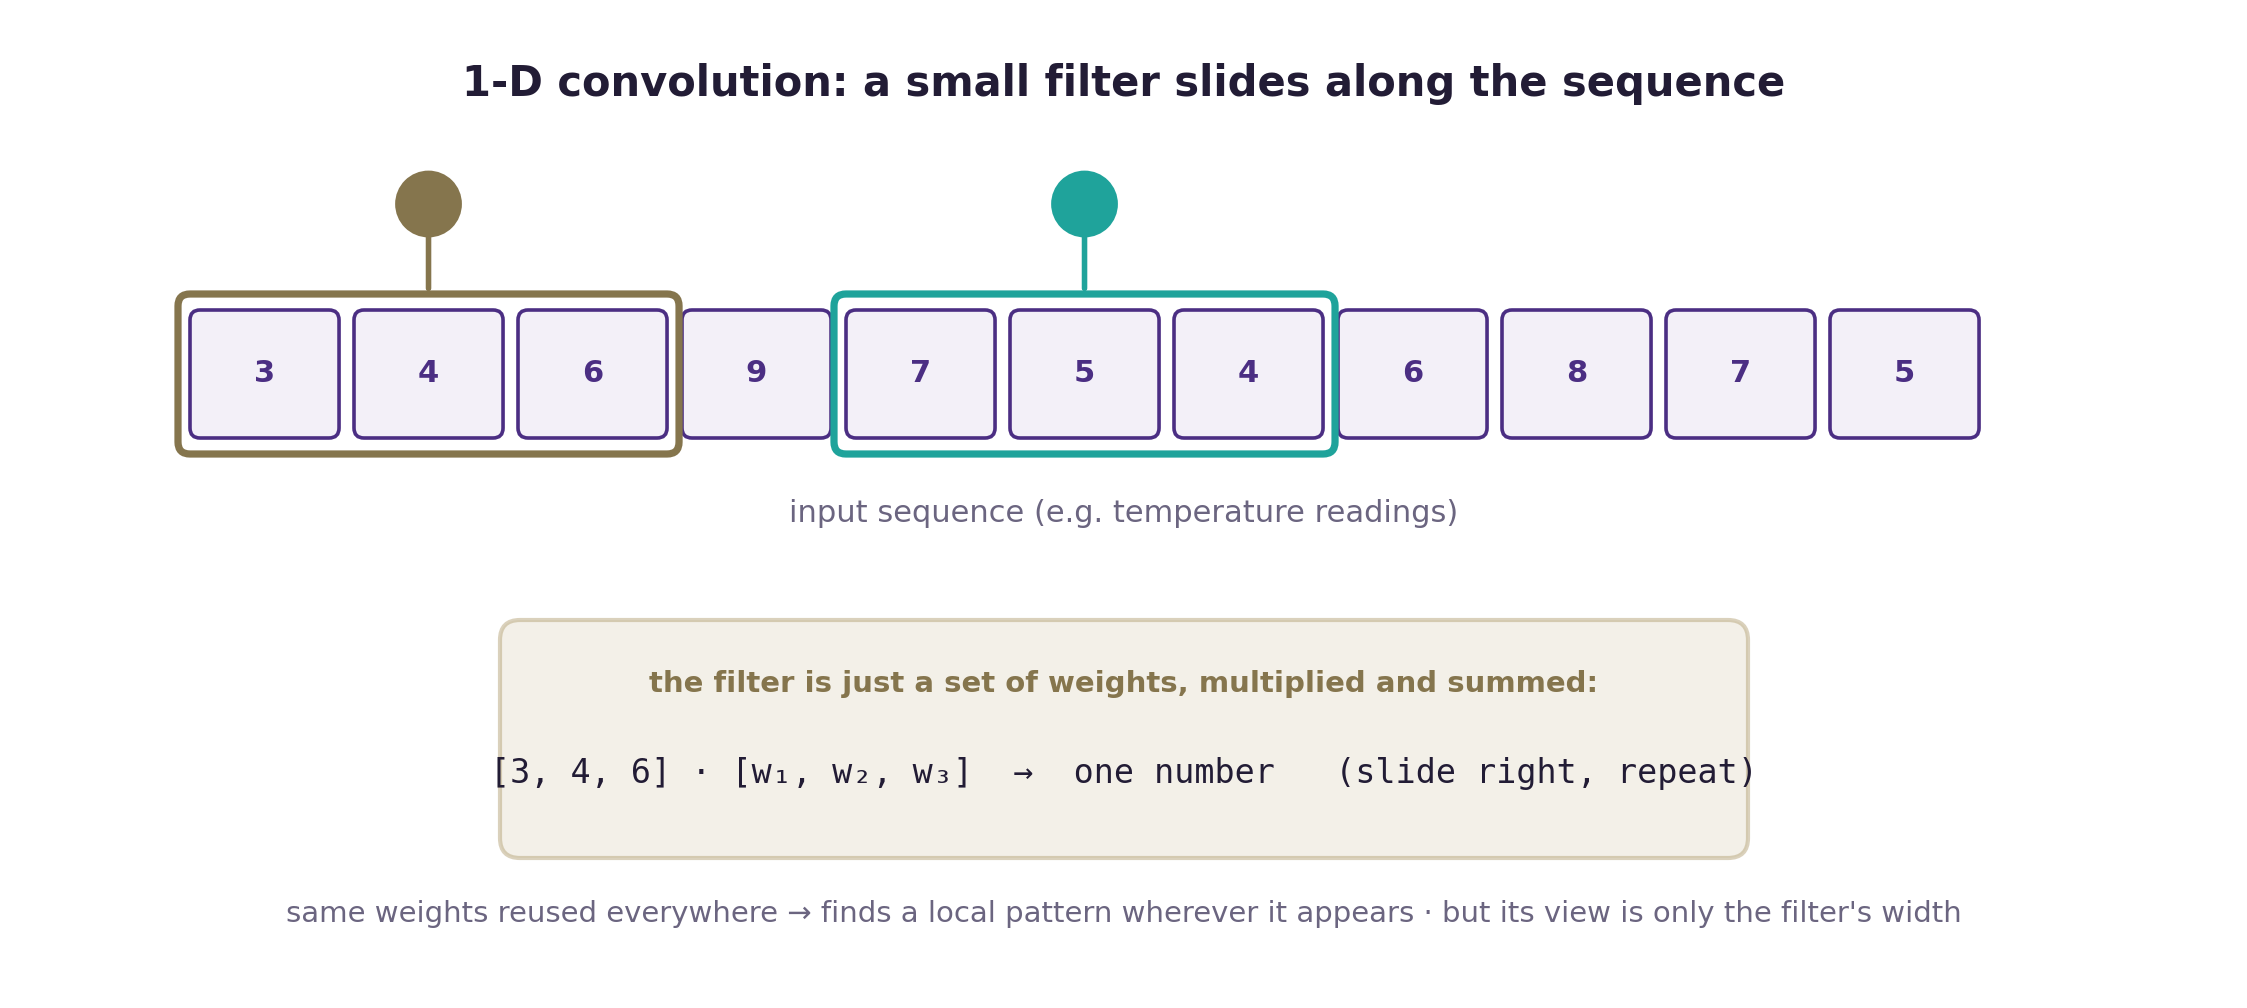</div>

The tradeoff is the filter's field of view: a kernel of size 5 can only look at 5 consecutive
timesteps at once. Stacking more convolution layers widens that view, but a 1-D CNN on its own has no
built-in way to combine information across the *whole* window, which is what the next model adds.


In [12]:
cnn = keras.Sequential([
    keras.Input(shape=(SEQ_LEN, N_FEAT)),
    layers.Conv1D(32, kernel_size=5, activation="relu"),
    layers.GlobalAveragePooling1D(),
    layers.Dense(1),
])
train_and_score(cnn, "cnn")

       cnn  val MAE =  3.89 °C   (loses to naive 2.82)


### 5c - SimpleRNN: memory across steps

A **recurrent neural network (RNN)** processes a sequence one timestep at a time, in order. At each
step it combines the current input with a **hidden state** (a vector summarizing everything seen so
far) to produce a new hidden state:

`h_t = tanh(W_x * x_t + W_h * h_(t-1) + b)`

The important part is that the same cell, and the same weights `W_x`, `W_h`, `b`, are reused at every
timestep. This is weight sharing again, now applied along time instead of across an image. Unrolling
the loop into a chain (right side of the diagram below) makes this concrete: it is the identical
small network, applied repeatedly.

<div align="center">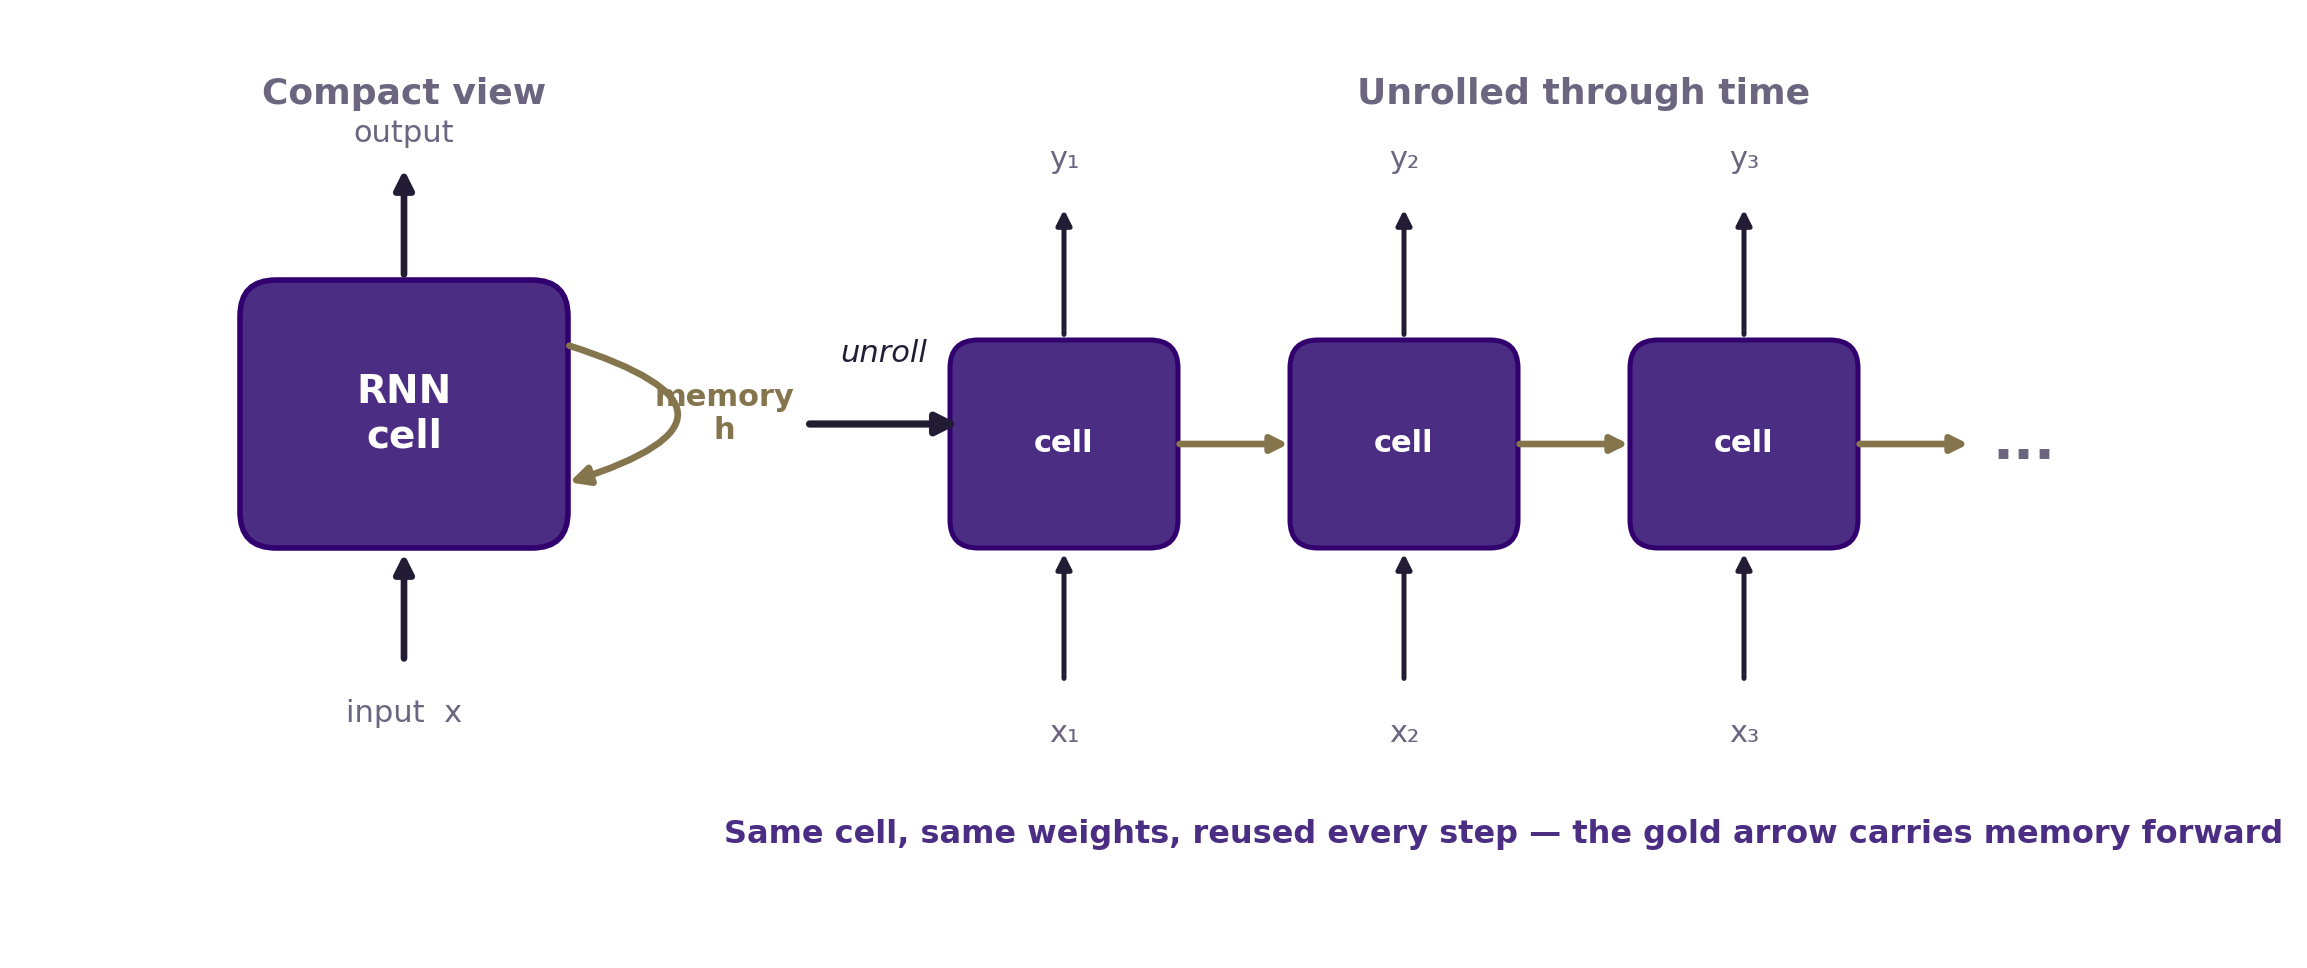</div>

The hidden state is best understood as a running summary: at every step,
`new summary = combine(old summary, new input)`. The circle below "fills up" as context accumulates:

<div align="center">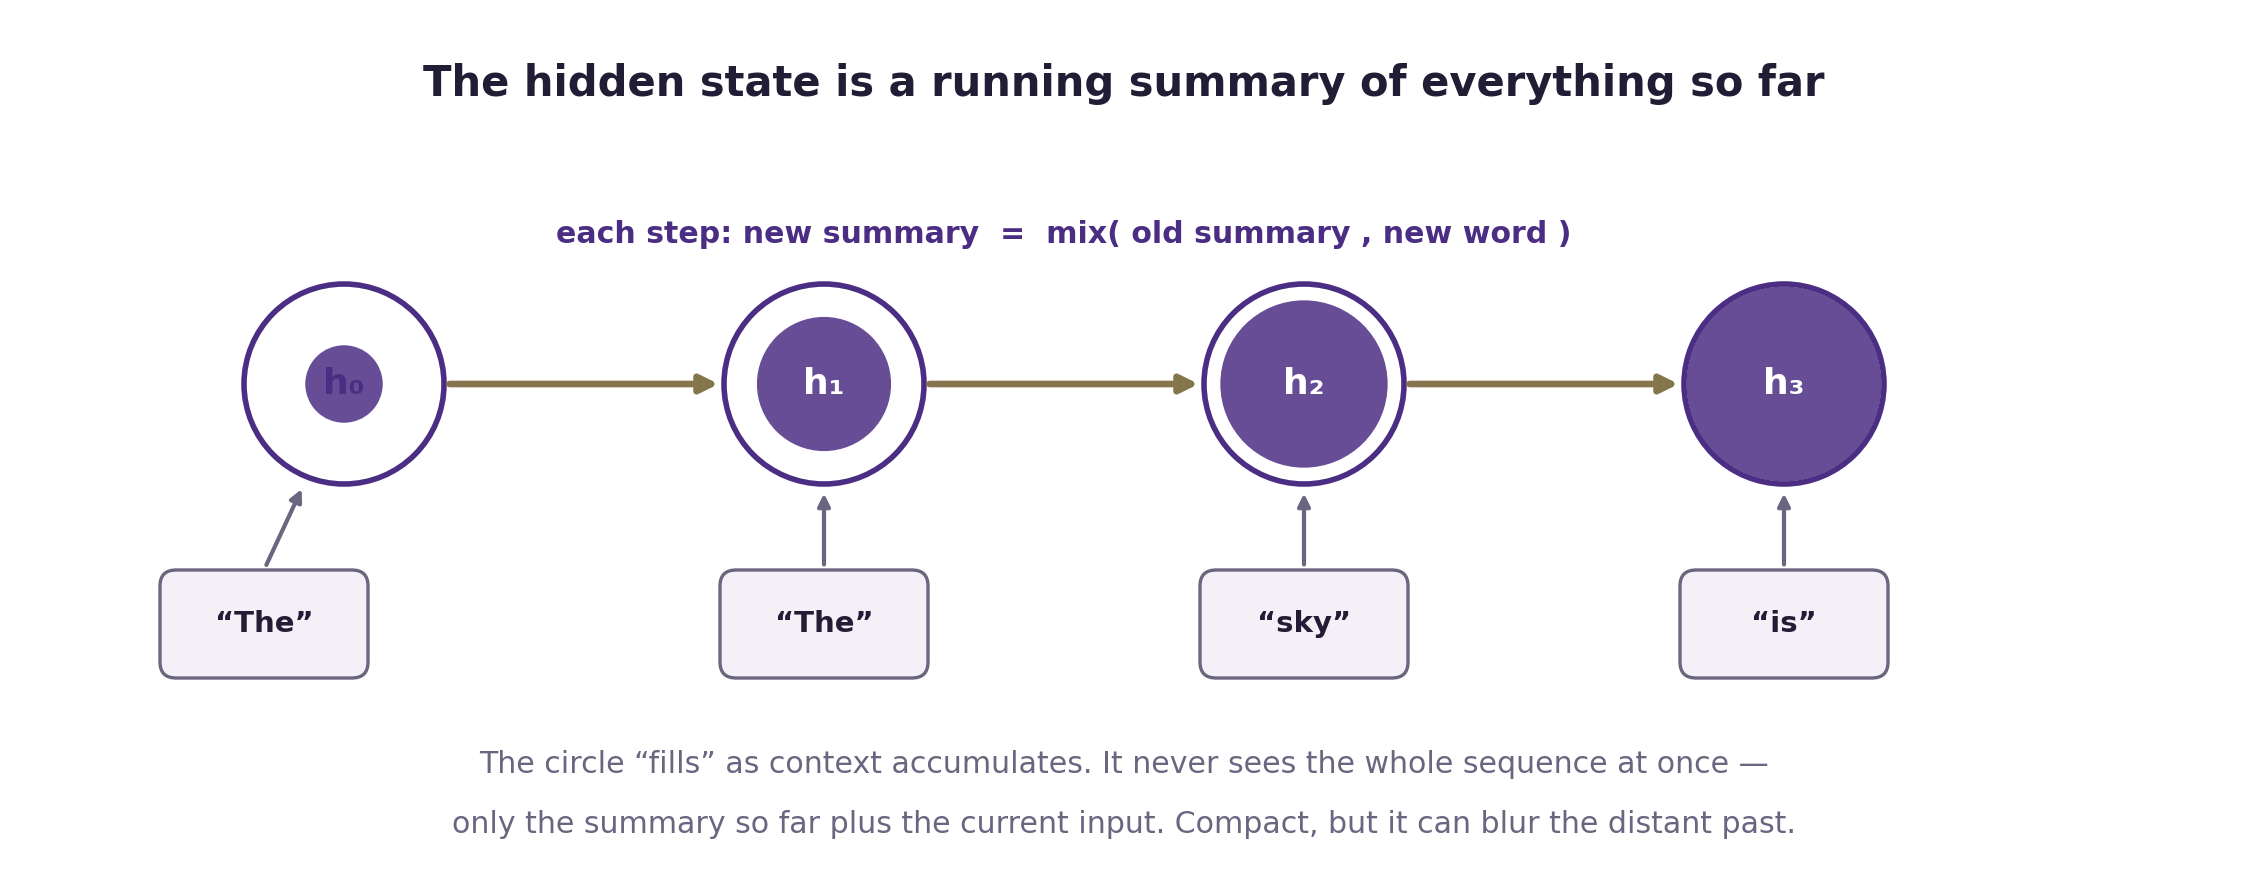</div>

Because the hidden state is a fixed-size vector that gets overwritten at every step, its capacity is
limited: information from many steps ago has to survive being repeatedly combined with newer inputs,
and in practice it tends to fade. That fading is the weakness the next model is built to fix.


In [13]:
rnn = keras.Sequential([
    keras.Input(shape=(SEQ_LEN, N_FEAT)),
    layers.SimpleRNN(32),
    layers.Dense(1),
])
train_and_score(rnn, "rnn")

       rnn  val MAE =  2.78 °C   (beats naive 2.82)


### 5d - LSTM: protected long memory

Before fixing the problem, it helps to see it stated plainly. During training, the error signal has
to travel backward through every timestep the network processed, a process called
**backpropagation through time**. At each step backward, the signal is multiplied by a small number,
so after many steps it shrinks toward zero: a well-known issue called the **vanishing gradient**. In
practice this means a plain RNN's weights barely update in response to something that happened far in
the past, so long-range dependencies (like a subject and a verb separated by many words) get lost.

<div align="center">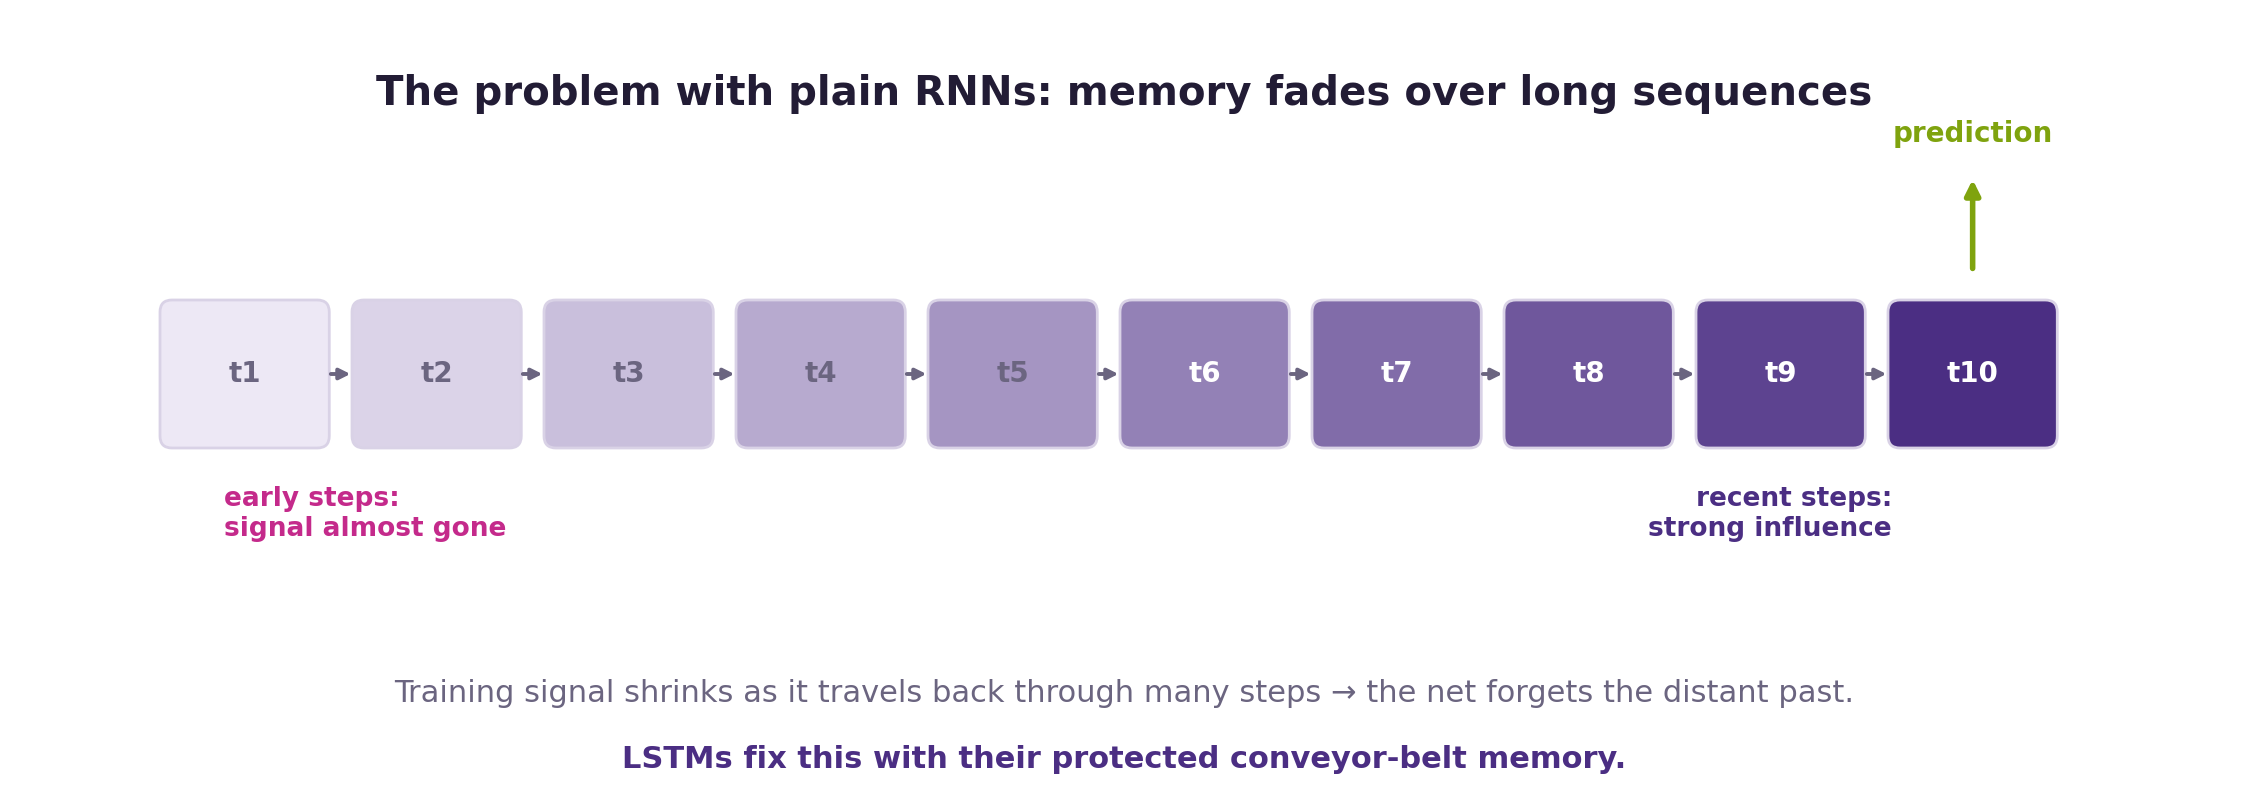</div>

The same idea, in its classic form: the earlier the relevant input (highlighted in red below), the
harder it is for that information to influence a distant output.

<div align="center">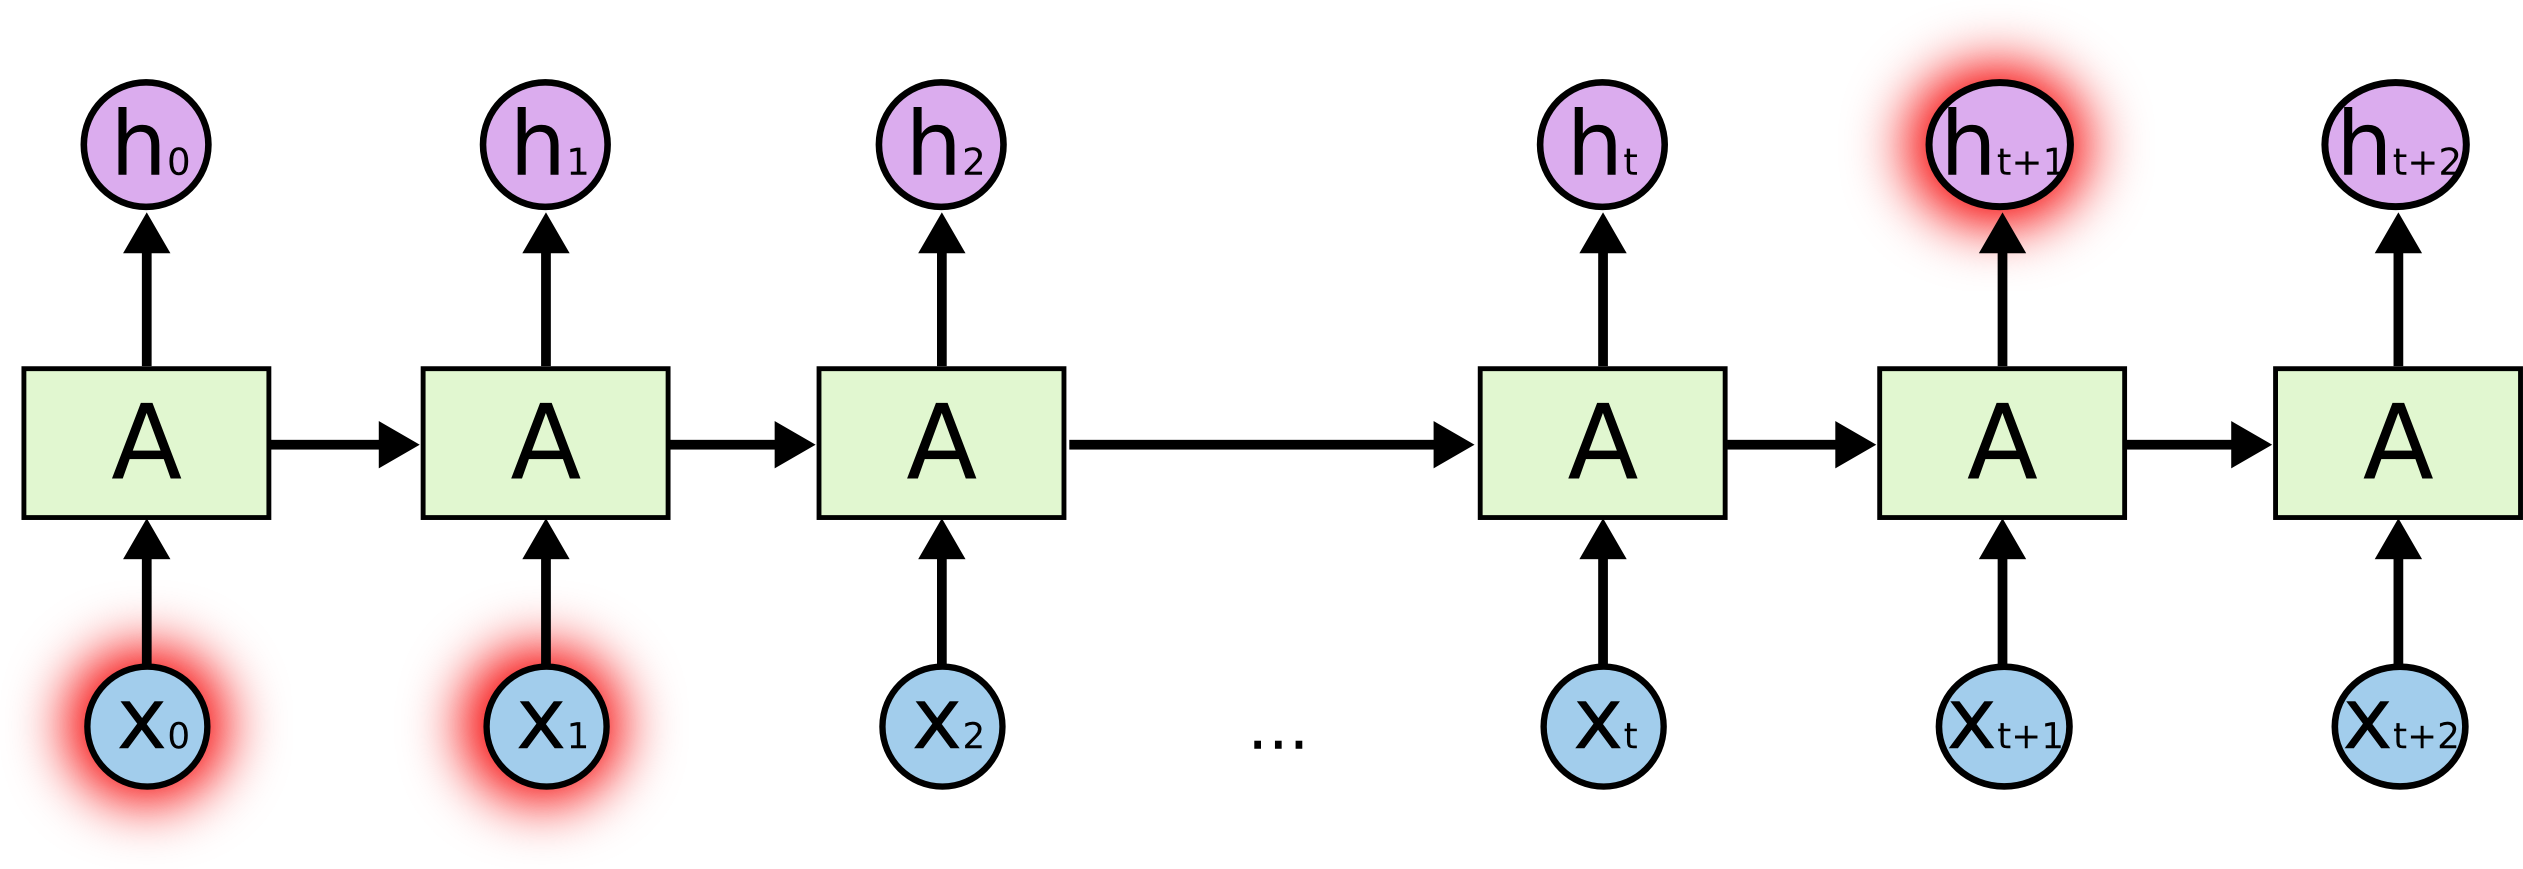</div>

*Source: Christopher Olah, "Understanding LSTM Networks," colah's blog, 2015.
[colah.github.io/posts/2015-08-Understanding-LSTMs](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)*

A **Long Short-Term Memory (LSTM)** cell fixes this by adding a second, protected pathway for memory,
the **cell state**, that flows across timesteps with only small, carefully controlled changes. Three
learned **gates**, each a sigmoid layer producing values between 0 (block) and 1 (pass), control how
the cell state is updated at every step:

- the **forget gate** decides what to drop from the cell state
- the **input gate** decides what new information to add
- the **output gate** decides what part of the cell state to expose as this step's hidden state

Because the cell state is only ever added to or partially forgotten, rather than fully overwritten as
in a SimpleRNN, useful information can survive across many more steps.

<div align="center">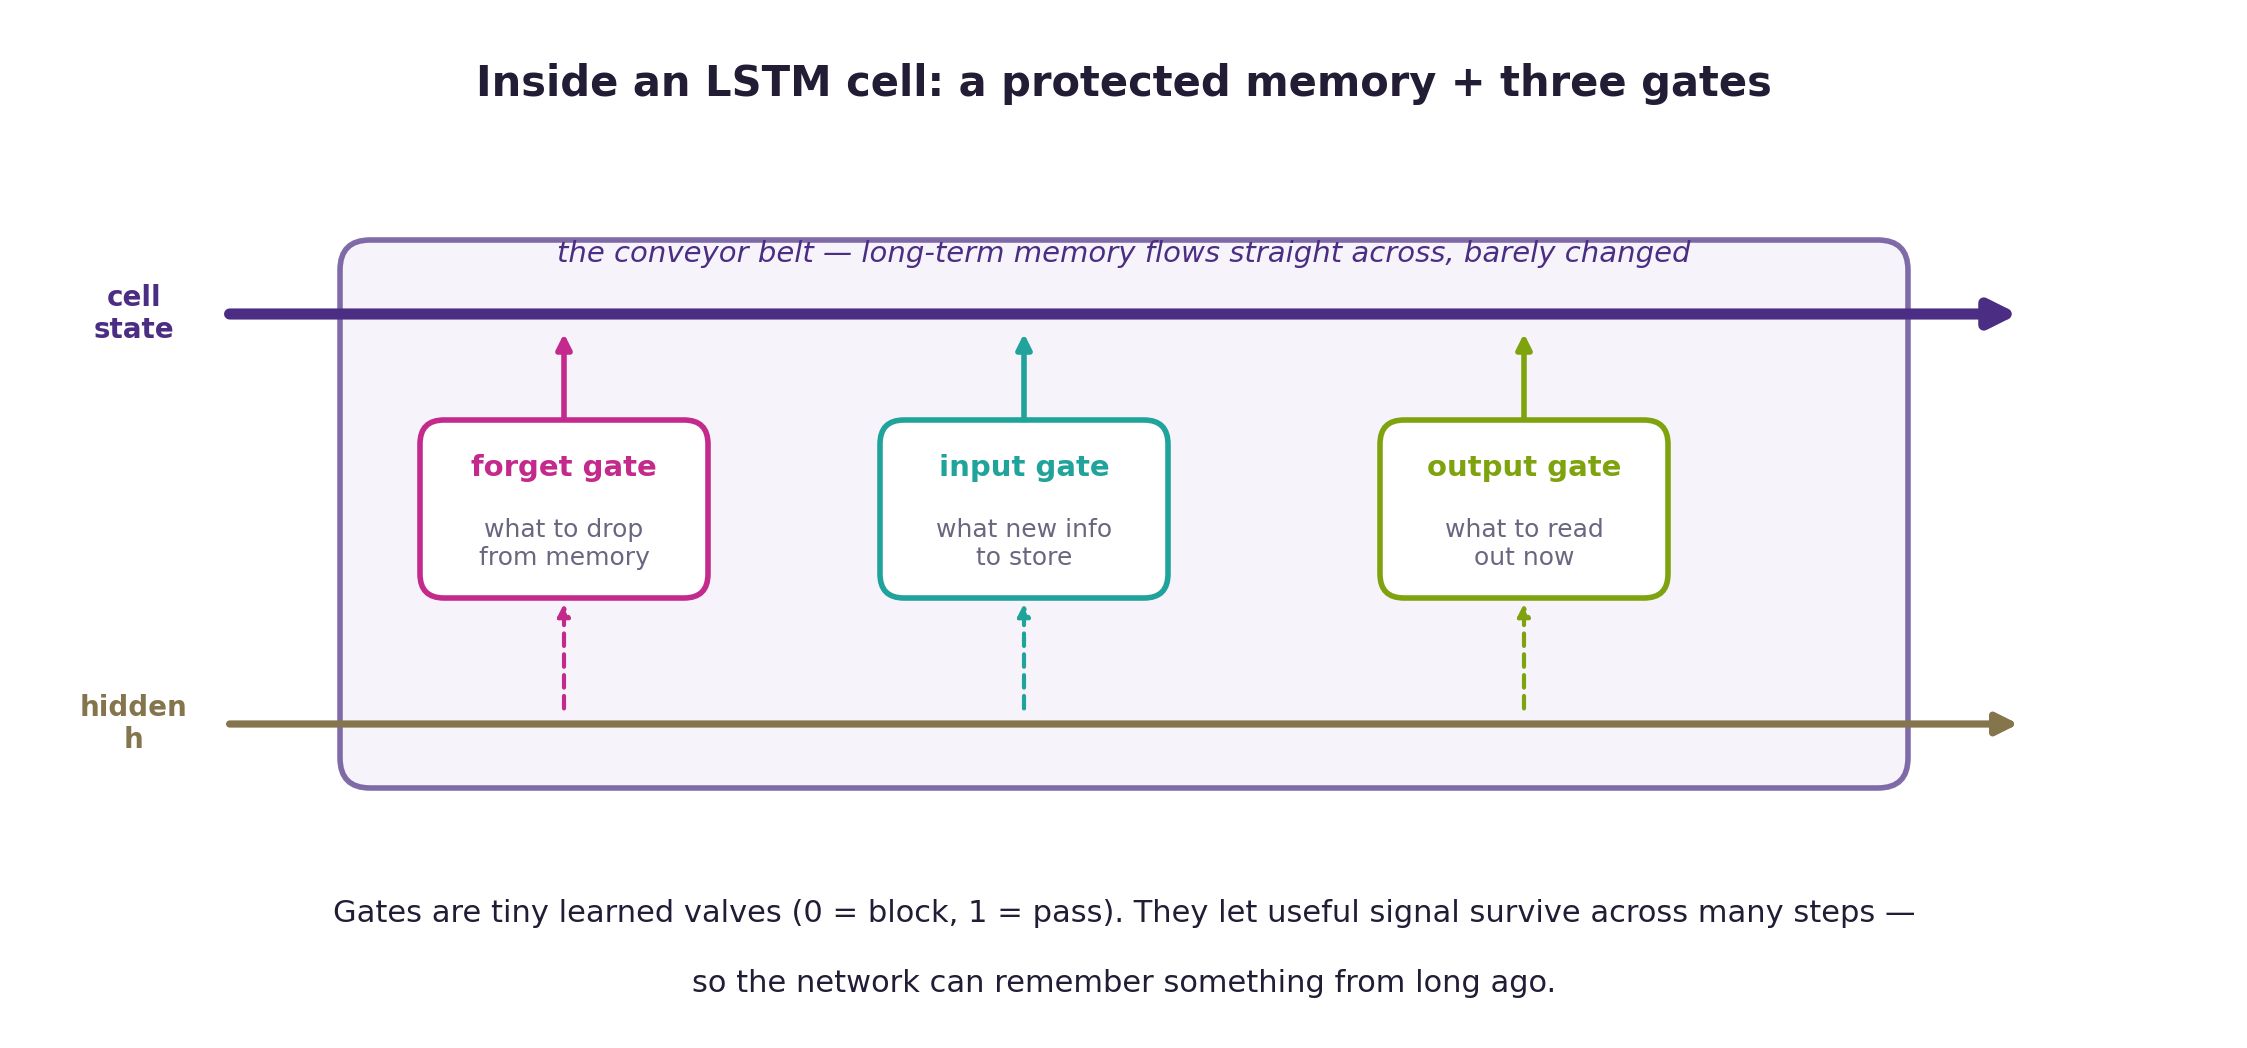</div>

For anyone who wants the full gating equations, here is the standard reference diagram
(sigma = sigmoid, tanh = the tanh activation, pink circles are elementwise operations):

<div align="center">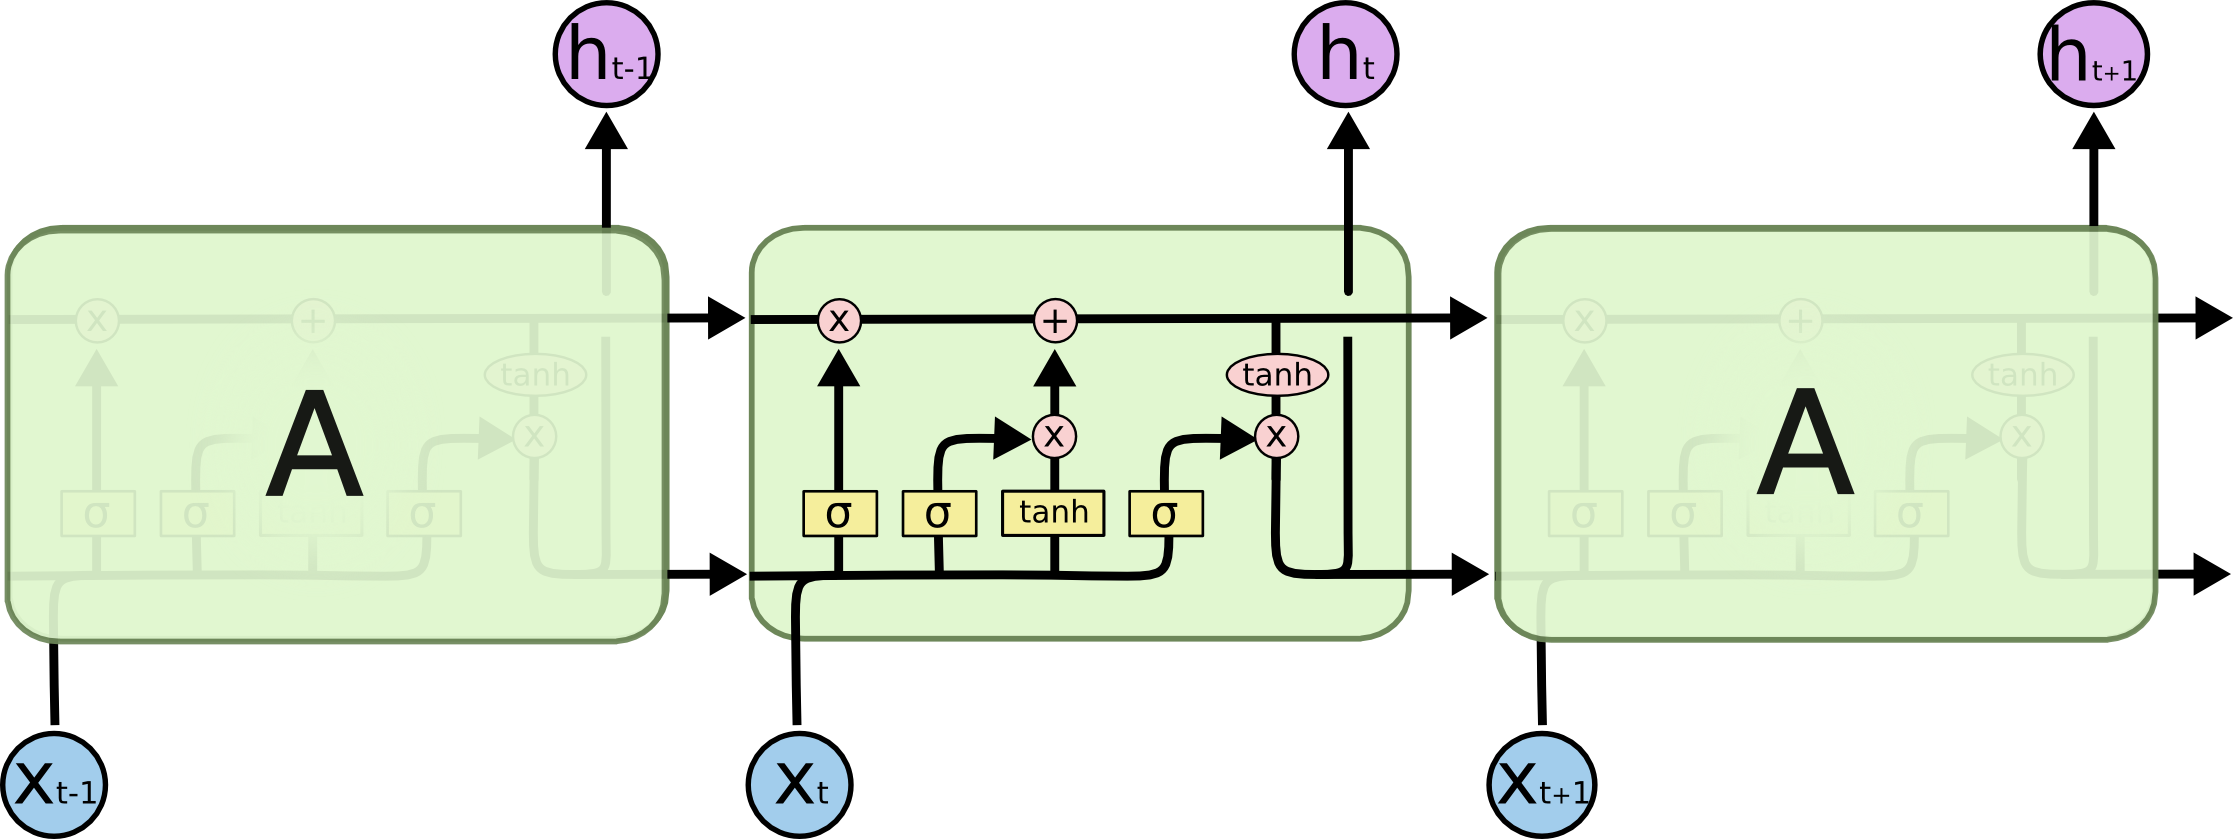</div>

*Source: Christopher Olah, "Understanding LSTM Networks," colah's blog, 2015.
[colah.github.io/posts/2015-08-Understanding-LSTMs](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)*

In code, the change from a SimpleRNN is a single line: swap `SimpleRNN` for `LSTM`. Keras handles the
gates internally.


In [14]:
lstm = keras.Sequential([
    keras.Input(shape=(SEQ_LEN, N_FEAT)),
    layers.LSTM(32),
    layers.Dense(1),
])
train_and_score(lstm, "lstm")

      lstm  val MAE =  3.24 °C   (loses to naive 2.82)


## 6 - Comparing all the models

The bar chart below plots each model's validation MAE next to the naive baseline (dashed line). A
model only earns its added complexity if it sits meaningfully below that line.


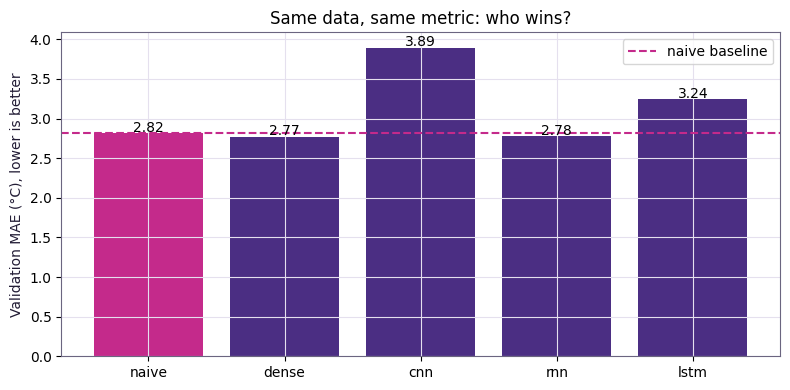

Best model: dense  (2.77 °C vs naive 2.82 °C)


In [15]:
names = list(results.keys())
vals  = [results[k] for k in names]
colors = [UW_PINK if k == "naive" else UW_PURPLE for k in names]

plt.figure(figsize=(8, 4))
bars = plt.bar(names, vals, color=colors)
plt.axhline(results["naive"], color=UW_PINK, ls="--", lw=1.5, label="naive baseline")
for b, v in zip(bars, vals):
    plt.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.2f}", ha="center", fontsize=10)
plt.ylabel("Validation MAE (°C), lower is better")
plt.title("Same data, same metric: who wins?")
plt.legend(); plt.tight_layout(); plt.show()

best = min((k for k in results if k != "naive"), key=lambda k: results[k])
print(f"Best model: {best}  ({results[best]:.2f} °C vs naive {results['naive']:.2f} °C)")

**Discuss:** which models beat the naive baseline, and by how much? On an easy,
short-horizon forecast like this one, the gap can be small, because persistence is already a strong
predictor when temperature changes slowly. That is not a failure of the notebook: it is an honest and
important result, and it previews two ideas that return later in the week (Thursday's evaluation
session and Friday's ethics session): always check that a model actually beats the trivial answer
before trusting it.


## 7 - Visualizing the predictions

A single MAE number hides *where* a model does well or poorly. Plotting predictions against the
actual values over time shows whether the model tracks slow trends, sharp turns, or both.


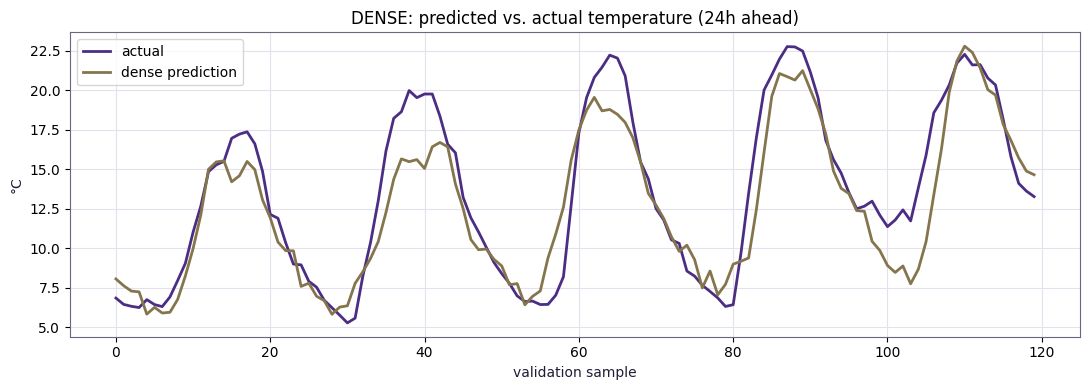

In [16]:
model_lookup = {"dense": dense, "cnn": cnn, "rnn": rnn, "lstm": lstm}
best_model = model_lookup[best]

xb, yb = next(iter(val_ds))
pred = best_model.predict(xb, verbose=0)[:, 0]

plt.figure(figsize=(11, 4))
plt.plot((yb.numpy()[:120]*sd+mu), label="actual", color=UW_PURPLE, lw=2)
plt.plot((pred[:120]*sd+mu), label=f"{best} prediction", color=UW_GOLD, lw=2)
plt.ylabel("°C"); plt.xlabel("validation sample")
plt.title(f"{best.upper()}: predicted vs. actual temperature ({DELAY}h ahead)")
plt.legend(); plt.tight_layout(); plt.show()

## 8 - Your turn

Pick one or more of the options below, then re-run section 6 to see how the comparison changes.

1. **Go bidirectional.** Wrap the LSTM in `layers.Bidirectional(...)`. A bidirectional RNN runs two
   copies of the recurrent layer, one reading the sequence forward and one reading it backward, and
   combines their hidden states at each step. Every position can then use context from both before
   and after it (see the diagram and the caveat below).

   <div align="center">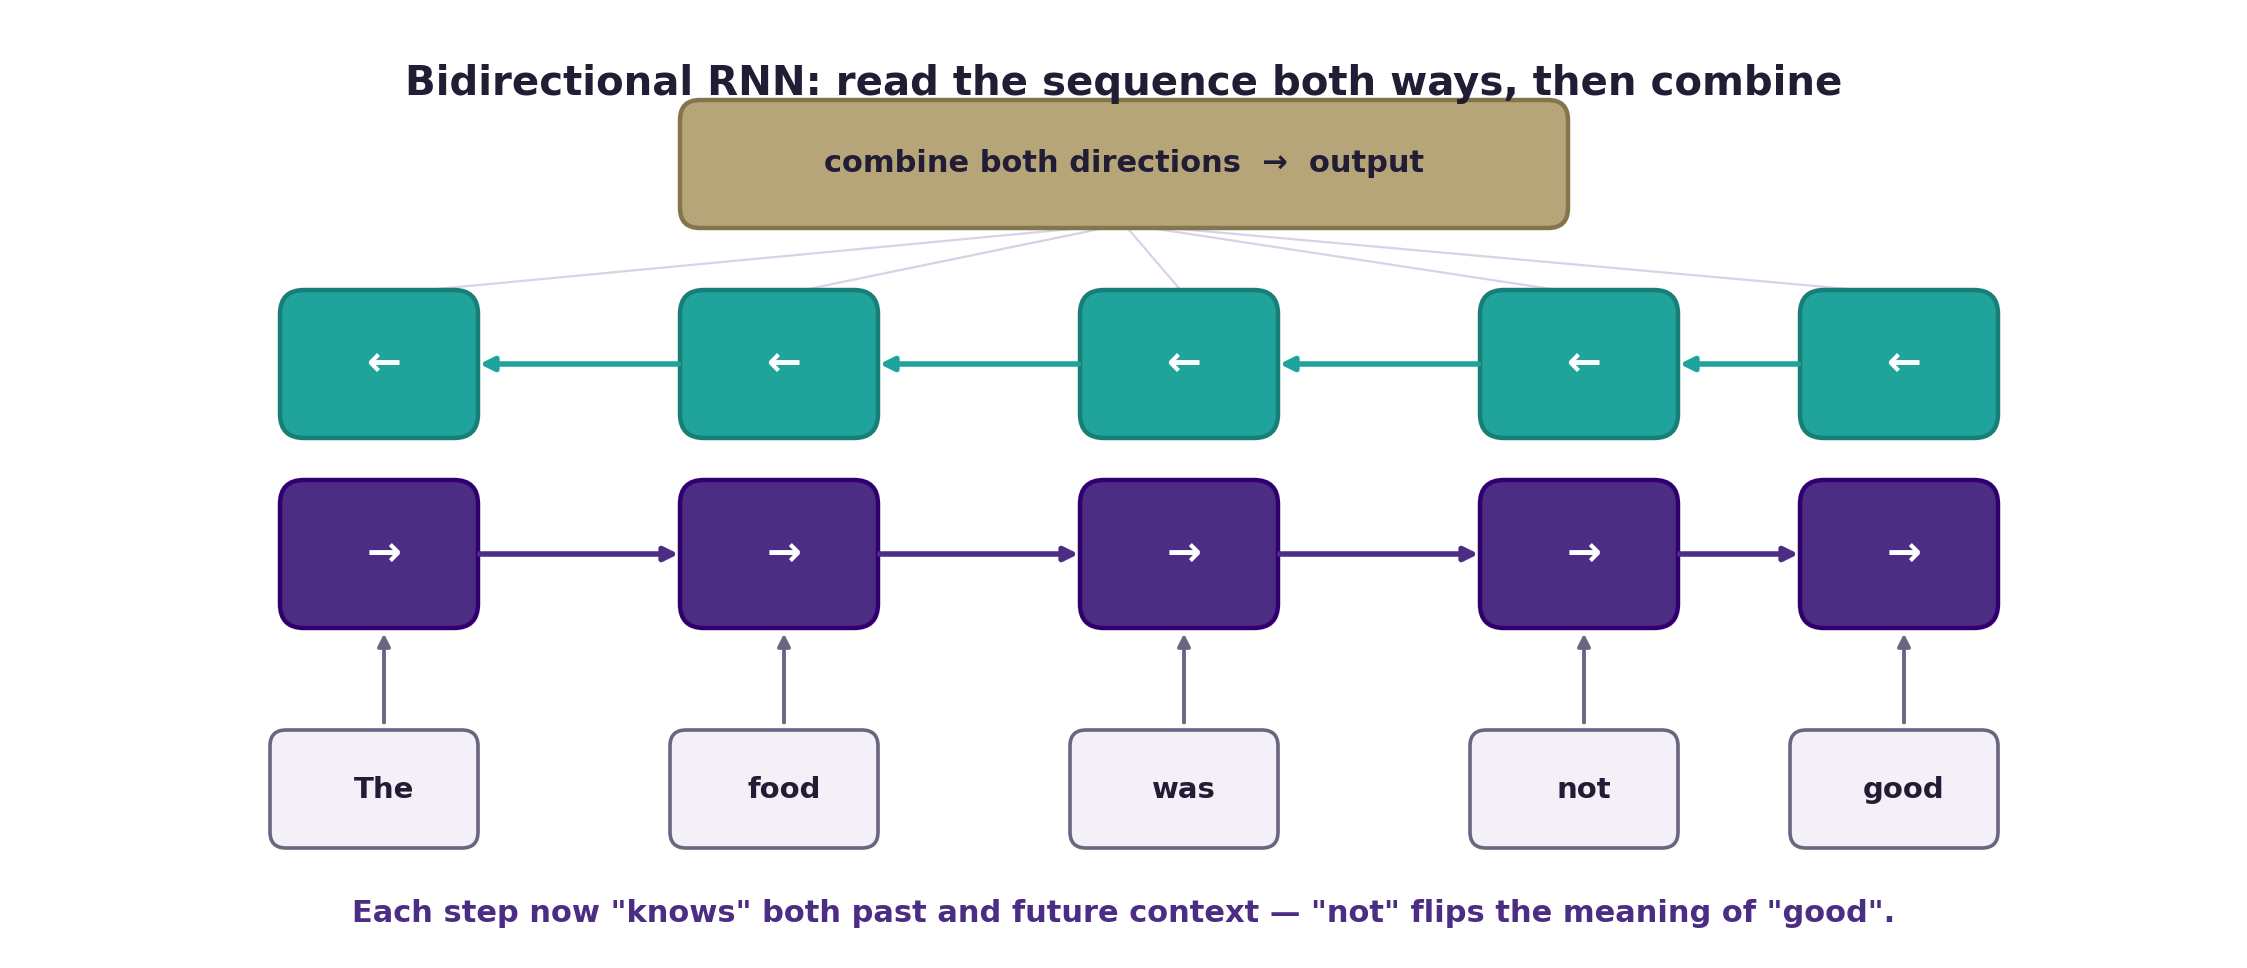</div>

2. **Go deeper.** Stack two LSTMs; the first one needs `return_sequences=True` so it outputs a hidden
   state at every timestep (not just the last one) for the second LSTM to consume.
3. **Change the window.** Try `SEQ_LEN = 120` (5 days of history) or `DELAY = 6` (predict 6 hours
   ahead instead of 24), and re-run from section 2 onward.

> This is the same exercise as Monday: add a layer or change a hyperparameter, then retrain. Same
> process, new architecture.


In [17]:
# 1) Bidirectional LSTM: wrap an LSTM in layers.Bidirectional(...)
bilstm = keras.Sequential([
    keras.Input(shape=(SEQ_LEN, N_FEAT)),
    layers.Bidirectional(layers.LSTM(32)),
    layers.Dense(1),
])
train_and_score(bilstm, "bilstm")

# 2) Stacked LSTM: first LSTM needs return_sequences=True
stacked = keras.Sequential([
    keras.Input(shape=(SEQ_LEN, N_FEAT)),
    layers.LSTM(32, return_sequences=True),
    layers.LSTM(32),
    layers.Dense(1),
])
train_and_score(stacked, "stacked")

    bilstm  val MAE =  3.30 °C   (loses to naive 2.82)
   stacked  val MAE =  3.30 °C   (loses to naive 2.82)


> **Note: the bidirectional trap.** A Bi-LSTM may score better here, but a real-time
> forecast does not have access to the future. Reading tomorrow's data to predict tomorrow's
> temperature is a form of data leakage: the model looks like it performs well, but the setup it was
> evaluated on could never happen in deployment. A good metric on a broken setup is exactly the kind
> of problem Friday's ethics session covers. Notice it, and think about what "having the whole
> sequence" actually requires for your own project.


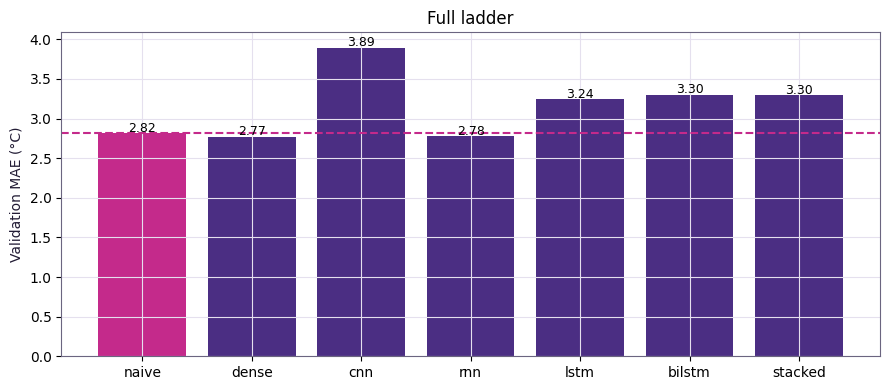

In [18]:
# Re-draw the comparison with your new models included:
names = list(results.keys()); vals = [results[k] for k in names]
colors = [UW_PINK if k=="naive" else UW_PURPLE for k in names]
plt.figure(figsize=(9,4))
bars = plt.bar(names, vals, color=colors)
plt.axhline(results["naive"], color=UW_PINK, ls="--", lw=1.5)
for b,v in zip(bars,vals): plt.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.2f}", ha="center", fontsize=9)
plt.ylabel("Validation MAE (°C)"); plt.title("Full ladder"); plt.tight_layout(); plt.show()

## 9 - Reflect: which shape is your project?

Sequence problems generally fall into one of four shapes, based on how many steps go in and how many
come out:

- **many-to-one**: a whole window of inputs collapses to a single output (what we did today: 48
  hours in, one temperature out)
- **one-to-many**: a single input or seed expands into a sequence of outputs (for example,
  generating a caption from one image)
- **many-to-many (aligned)**: one output per input step, in lockstep (for example, tagging every
  word in a sentence with a part of speech)
- **seq2seq (many-to-many, unaligned)**: an input sequence maps to an output sequence of a different
  length (for example, translating a sentence between languages)

| Your data looks like... | ...then reach for |
|---|---|
| one label for a whole window | **many-to-one** (what we did today) |
| a sequence generated from a seed | **one-to-many** |
| a label for every timestep | **many-to-many (aligned)** |
| one sequence mapped to another | **seq2seq** (tomorrow's transformers shine here) |


## 10 - Takeaways

- A **sequence** is defined by order and variable length, and that is exactly what today's models
  are built to exploit.
- Always build a naive baseline first. It keeps every later result honest.
- 1-D CNNs detect local patterns using weight sharing across a small window. RNNs and LSTMs carry a
  hidden state across steps, and LSTMs specifically protect long-range memory using gates.
  Bidirectional models read the sequence in both directions, which requires the whole sequence in
  advance, so they are not appropriate for real-time forecasting.
- The same `(window -> target)` framing used here for forecasting also applies to anomaly detection,
  classifying a time window, and other tasks.

### Looking ahead to tomorrow

RNNs and LSTMs read a sequence one step at a time. That is slow (it cannot be parallelized across
time) and it still strains on very long sequences. Tomorrow's session introduces the idea that
addresses both limitations: **attention**, and the architecture built around it, the
**Transformer**. Bidirectional processing also returns tomorrow at a much larger scale, in a model
called **BERT**.

<div align="center" style="color:#4B2E83;font-weight:bold">
University of Washington, eScience Institute. See you tomorrow for transformers.
</div>
